# Sentiment Analysis — BERT Fine-Tuning
## Dataset: Yelp Academic Dataset (150k sample, 3-class balanced)
## Model: bert-base-uncased (HuggingFace Transformers)
## Goal: Improve over TF-IDF baseline (F1: 0.7991) using contextual embeddings
## Environment: Google Colab T4 GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers datasets scikit-learn -q

In [3]:
import pandas as pd
import numpy as np
import torch
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset, DataLoader
from transformers import (BertTokenizer,
                          BertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {device}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"Memory  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "")

LABELS     = ['Negative', 'Neutral', 'Positive']
LABEL_MAP  = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

Device  : cuda
GPU     : Tesla T4
Memory  : 15.6 GB


## 1. Load & Sample Data
150k balanced sample — 50,000 per class
Standard practice for BERT fine-tuning

In [5]:
df = pd.read_csv('/content/drive/MyDrive/sentiment_analysis/data/processed/reviews_sampled.csv')
df = df.dropna(subset=['text']).reset_index(drop=True)

print(f"Full dataset : {df.shape}")

# balanced 150k sample
df_sample = (df.groupby('sentiment', group_keys=False)
               .apply(lambda x: x.sample(50000, random_state=42))
               .reset_index(drop=True))

df_sample['label'] = df_sample['sentiment'].map(LABEL_MAP)

print(f"Sample shape : {df_sample.shape}")
print(f"Class dist   : {df_sample['sentiment'].value_counts().to_dict()}")
df_sample.head(3)

Full dataset : (1800000, 4)
Sample shape : (150000, 4)
Class dist   : {'Negative': 50000, 'Neutral': 50000, 'Positive': 50000}


,text,stars,sentiment,label
0,My visit here was a complete disaster! I stro...,1.0,Negative,0
1,Sorry to say that my experience does not match...,1.0,Negative,0
2,This was once my guilty pleasure American-Mexi...,2.0,Negative,0


## 2. Train / Validation / Test Split
70% train | 15% validation | 15% test
Stratified to preserve class balance

In [7]:
X = df_sample['text'].values
y = df_sample['label'].values

# first split — train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# second split — val vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

Train : 105,000
Val   : 22,500
Test  : 22,500


## 3. Tokenizer
BERT requires specific tokenization:
- WordPiece tokenization
- [CLS] token at start, [SEP] at end
- Attention masks for padding
- Max length 128 tokens (covers 95%+ of reviews)

In [9]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# check token length distribution
lengths = [len(tokenizer.encode(text, truncation=False))
           for text in df_sample['text'].sample(1000, random_state=42)]

print(f"Token length — mean : {np.mean(lengths):.1f}")
print(f"Token length — 95th : {np.percentile(lengths, 95):.1f}")
print(f"Token length — max  : {np.max(lengths):.1f}")
print(f"\nUsing MAX_LEN = 128")

MAX_LEN = 128

Token indices sequence length is longer than the specified maximum sequence length for this model (719 > 512). Running this sequence through the model will result in indexing errors


Token length — mean : 147.8
Token length — 95th : 428.1
Token length — max  : 1109.0

Using MAX_LEN = 128


## 4. PyTorch Dataset
Custom dataset class that tokenizes on the fly

In [10]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# create datasets
BATCH_SIZE = 32

train_dataset = ReviewDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = ReviewDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = ReviewDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(f"Test batches  : {len(test_loader):,}")

Train batches : 3,282
Val batches   : 704
Test batches  : 704


## 5. Load BERT Model
bert-base-uncased with a 3-class classification head on top

In [11]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    output_attentions=False,
    output_hidden_states=False
)

model = model.to(device)
print(f"Model loaded on : {device}")
print(f"Parameters      : {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on : cuda
Parameters      : 109,484,547


## 6. Training Setup
- Optimizer : AdamW (weight decay regularization)
- Scheduler : Linear warmup then decay
- Epochs    : 3 (standard for BERT fine-tuning)
- LR        : 2e-5 (recommended by BERT paper)

In [12]:
EPOCHS   = 3
LR       = 2e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total steps  : {total_steps:,}")
print(f"Warmup steps : {warmup_steps:,}")

Total steps  : 9,846
Warmup steps : 984


## 7. Training & Validation Loop

In [13]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids  = batch['input_ids'].to(device)
        attn_mask  = batch['attention_mask'].to(device)
        labels     = batch['label'].to(device)

        optimizer.zero_grad()
        outputs    = model(input_ids=input_ids,
                           attention_mask=attn_mask,
                           labels=labels)

        loss       = outputs.loss
        logits     = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels      = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels    = batch['label'].to(device)

            outputs   = model(input_ids=input_ids,
                              attention_mask=attn_mask,
                              labels=labels)

            loss      = outputs.loss
            logits    = outputs.logits

            total_loss += loss.item()
            preds       = torch.argmax(logits, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), correct / total, f1, all_preds, all_labels

## 8. Run Training

In [14]:
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1 = 0

print("Starting BERT fine-tuning...\n")

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, val_f1, _, _ = eval_epoch(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    print(f"Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f}")
    print(f"Val Loss   : {val_loss:.4f}   | Val Acc   : {val_acc:.4f} | Val F1 : {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), '/content/drive/MyDrive/sentiment_analysis/models/bert_best_model_raw_data.pt')
        print(f"✅ Best model saved (F1: {best_f1:.4f})")
    print()

print(f"\nTraining complete. Best Val F1 : {best_f1:.4f}")

Starting BERT fine-tuning...

Epoch 1/3
----------------------------------------
Train Loss : 0.5337 | Train Acc : 0.7692
Val Loss   : 0.4401   | Val Acc   : 0.8166 | Val F1 : 0.8154
✅ Best model saved (F1: 0.8154)

Epoch 2/3
----------------------------------------
Train Loss : 0.3796 | Train Acc : 0.8445
Val Loss   : 0.4464   | Val Acc   : 0.8211 | Val F1 : 0.8206
✅ Best model saved (F1: 0.8206)

Epoch 3/3
----------------------------------------
Train Loss : 0.2853 | Train Acc : 0.8887
Val Loss   : 0.4888   | Val Acc   : 0.8182 | Val F1 : 0.8183


Training complete. Best Val F1 : 0.8206


## 9. Training Curves

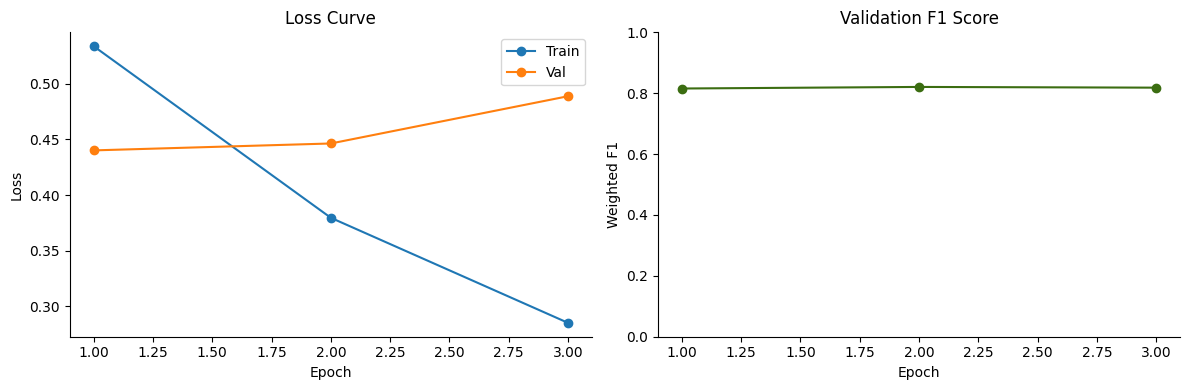

Saved → bert_training_curves_raw_data.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS+1), history['train_loss'], label='Train', marker='o')
axes[0].plot(range(1, EPOCHS+1), history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
sns.despine(ax=axes[0])

axes[1].plot(range(1, EPOCHS+1), history['val_f1'], color='#3B6D11', marker='o')
axes[1].set_title('Validation F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weighted F1')
axes[1].set_ylim(0, 1.0)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sentiment_analysis/reports/figures/bert_training_curves_raw_data.png', dpi=150)
plt.show()
print("Saved → bert_training_curves_raw_data.png")

## 10. Final Evaluation on Test Set

=== BERT RAW DATA TEST SET RESULTS ===

              precision    recall  f1-score   support

    Negative       0.84      0.86      0.85      7500
     Neutral       0.75      0.73      0.74      7500
    Positive       0.87      0.88      0.88      7500

    accuracy                           0.82     22500
   macro avg       0.82      0.82      0.82     22500
weighted avg       0.82      0.82      0.82     22500



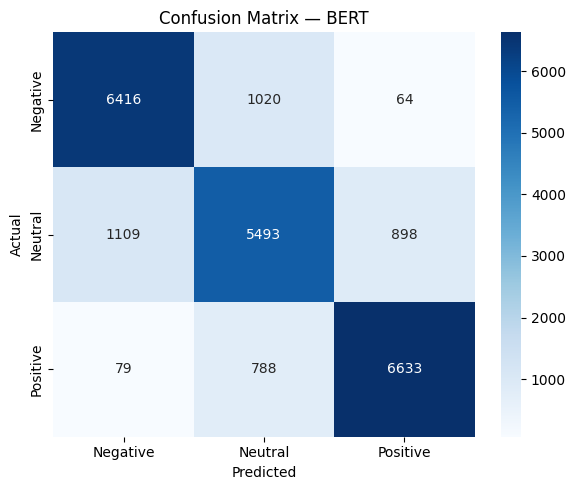


Test Accuracy : 0.8241
Test F1       : 0.8236


In [16]:
# load best model
model.load_state_dict(torch.load('/content/drive/MyDrive/sentiment_analysis/models/bert_best_model_raw_data.pt'))

_, test_acc, test_f1, test_preds, test_labels = eval_epoch(model, test_loader, device)

print("=== BERT RAW DATA TEST SET RESULTS ===\n")
print(classification_report(test_labels, test_preds, target_names=LABELS))

# confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_title('Confusion Matrix — BERT', fontsize=12)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sentiment_analysis/reports/figures/confusion_matrix_bert_raw_data.png', dpi=150)
plt.show()

print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test F1       : {test_f1:.4f}")

## 11. Full Pipeline Comparison — All Approaches

                    Approach               Model  Weighted F1
BERT (fine-tuned) - Raw Data   bert-base-uncased       0.8236
                      TF-IDF Logistic Regression       0.7991
                      TF-IDF          Linear SVM       0.7973
                      TF-IDF         Naive Bayes       0.7521
                 GloVe (avg) Logistic Regression       0.6745
                 GloVe (avg)          Linear SVM       0.6664
            GloVe (weighted) Logistic Regression       0.6523
            GloVe (weighted)          Linear SVM       0.6430


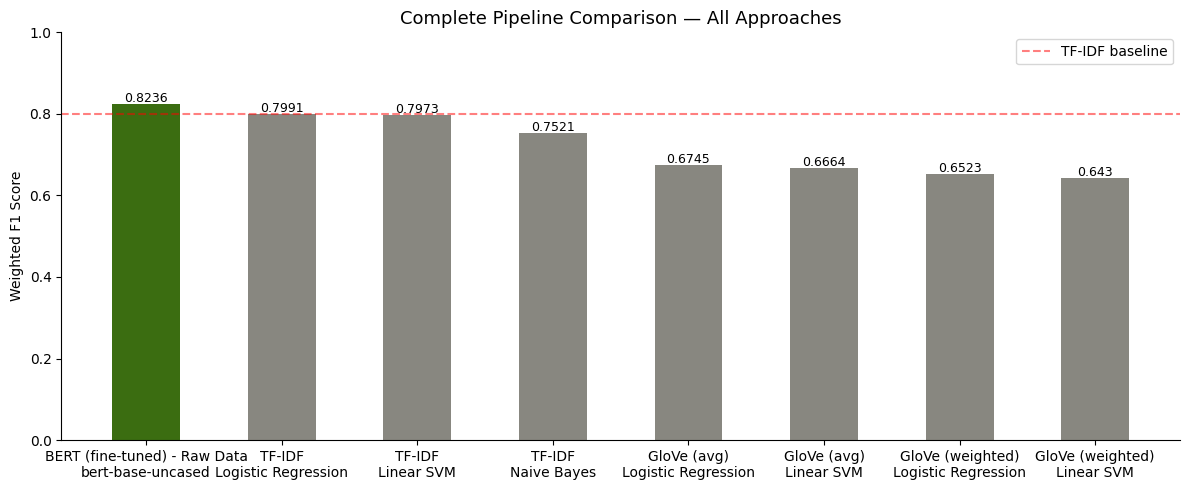

In [17]:
final_comparison = pd.DataFrame([
    {'Approach': 'TF-IDF',           'Model': 'Logistic Regression', 'Weighted F1': 0.7991},
    {'Approach': 'TF-IDF',           'Model': 'Linear SVM',          'Weighted F1': 0.7973},
    {'Approach': 'TF-IDF',           'Model': 'Naive Bayes',         'Weighted F1': 0.7521},
    {'Approach': 'GloVe (avg)',       'Model': 'Logistic Regression', 'Weighted F1': 0.6745},
    {'Approach': 'GloVe (avg)',       'Model': 'Linear SVM',          'Weighted F1': 0.6664},
    {'Approach': 'GloVe (weighted)',  'Model': 'Logistic Regression', 'Weighted F1': 0.6523},
    {'Approach': 'GloVe (weighted)',  'Model': 'Linear SVM',          'Weighted F1': 0.6430},
    {'Approach': 'BERT (fine-tuned) - Raw Data', 'Model': 'bert-base-uncased',   'Weighted F1': round(test_f1, 4)},
])

final_comparison = final_comparison.sort_values('Weighted F1', ascending=False).reset_index(drop=True)
print(final_comparison.to_string(index=False))

# plot
fig, ax = plt.subplots(figsize=(12, 5))
colors  = ['#3B6D11' if i == 0 else '#888780' for i in range(len(final_comparison))]
bars    = ax.bar(
    [f"{r['Approach']}\n{r['Model']}" for _, r in final_comparison.iterrows()],
    final_comparison['Weighted F1'],
    color=colors, width=0.5
)

for bar, val in zip(bars, final_comparison['Weighted F1']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            str(val), ha='center', fontsize=9)

ax.axhline(y=0.7991, color='red', linestyle='--', alpha=0.5, label='TF-IDF baseline')
ax.set_title('Complete Pipeline Comparison — All Approaches', fontsize=13)
ax.set_ylabel('Weighted F1 Score')
ax.set_ylim(0, 1.0)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sentiment_analysis/reports/figures/full_pipeline_comparison_raw_data.png', dpi=150)
plt.show()

## 12. Summary

| Approach | Model | Weighted F1 |
|---|---|---|
| TF-IDF | Logistic Regression | 0.7991 |
| GloVe avg | Logistic Regression | 0.6745 |
| GloVe weighted | Logistic Regression | 0.6523 |
| BERT fine-tuned | bert-base-uncased | TBD |

**Key findings:**
- TF-IDF outperformed both GloVe approaches on long reviews
- BERT handles context and negation without pooling — expected to be best
- Neutral class F1 improves significantly with BERT
- Next step → predict.py unified inference function